# 2D Heat Equation — DD-ANN (Compact Hard-BC Architecture)
## SRIP 2026 — IIT Gandhinagar | DD-ANN Phase 5

---

## Why the Previous Version Was Slow and Inaccurate

| Problem | Previous DD-ANN | **This Notebook** |
|---------|----------------|-------------------|
| Architecture | 4 layers × 64 neurons | **3 layers × 32 neurons** |
| Params per network | 12,737 | **2,273** |
| Total params (2 nets) | 25,474 | **4,546** |
| BC enforcement | Soft (4-term loss) | **Hard (IC + spatial walls exact)** |
| Loss terms | PDE + global BC + interface + IC | **PDE + interface only** |
| LR scheduler | None | **ExponentialLR (persists across iters)** |
| BC/IC sampling overhead | Yes (3 extra point sets) | **None** |

## Hard BC Construction (Key Insight)

For zero-Dirichlet problems with IC $u_0(x,y)$:

$$u_\theta(x,y,t) = \underbrace{u_0(x,y)}_{\text{exact IC at } t=0} + t \cdot \underbrace{\text{mask}(x,y)}_{\text{zero at walls}} \cdot N(x,y,t)$$

- **IC satisfied:** at $t=0$, the $t\cdot$ term vanishes → $u = u_0(x,y)$ exactly
- **Ω₁ walls (x=0, y=0, y=1):** mask $= x\cdot y(1-y) = 0$, and $u_0 = 0$ there → $u=0$ ✓
- **Ω₂ walls (x=1, y=0, y=1):** mask $= (1-x)\cdot y(1-y) = 0$ → $u=0$ ✓
- **Interface (x=x_b or x=x_a):** mask $\neq 0$ → **only one soft term remains**

## Three Test Problems

| # | Exact $u(x,y,t)$ | $\alpha$ | $T$ |
|---|-----------------|----------|-----|
| 1 | $e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y)$ | 0.1 | 1.0 |
| 2 | $e^{-5\alpha\pi^2 t}\sin(\pi x)\sin(2\pi y)$ | 0.1 | 0.5 |
| 3 | $e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y) + 0.5e^{-8\alpha\pi^2 t}\sin(2\pi x)\sin(2\pi y)$ | 0.1 | 0.5 |

## Section 1 — Imports & Reproducibility

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print(f"PyTorch {torch.__version__} | Device: {device}")

PyTorch 2.12.0+cpu | Device: cpu


## Section 2 — Hard BC Network Architecture

### Subdomain network (Ω₁ or Ω₂)

The mask differs per subdomain:
- **Ω₁** (left, global wall at $x=0$): mask $= x \cdot y(1-y)$
- **Ω₂** (right, global wall at $x=1$): mask $= (1-x) \cdot y(1-y)$

Both masks are zero on their global spatial walls AND zero at $y=0,1$.
Neither mask is zero at the interface — the interface is the one remaining soft coupling.

### Global PINN (single domain baseline)

Uses mask $= x(1-x)\cdot y(1-y)$ — zero on all 4 spatial edges.
Loss has **zero boundary/IC terms** — only PDE residual. The simplest possible loss.

### Why autodiff still works through $u_0(x,y)$

When computing $-\Delta u = -(u_{xx}+u_{yy})$, autodiff differentiates through
the entire forward pass including the $u_0$ term. This correctly captures
$(u_0)_{xx}$ and $(u_0)_{yy}$ in the Laplacian — no special treatment needed.

In [2]:
class HardBC_Heat_Sub(nn.Module):
    """
    Compact subdomain PINN for 2D heat equation with HARD BCs.
    Architecture: 3 hidden layers x 32 neurons = 2,273 parameters.

    Forward:
        u(x,y,t) = u0(x,y)  +  t * mask(x,y) * N(x,y,t)

    Hard-enforced (exact, zero residual by construction):
        Ω₁: IC u(x,y,0) = u0(x,y), walls x=0, y=0, y=1
        Ω₂: IC u(x,y,0) = u0(x,y), walls x=1, y=0, y=1

    Soft-enforced (one penalty term):
        Interface: u(x_if,y,t) = other_net(x_if,y,t)
    """
    def __init__(self, ic_func, side='left',
                 hidden_layers=3, hidden_size=32):
        super().__init__()
        self.ic_func = ic_func   # u0(xy) → (N,1)
        self.side    = side      # 'left' or 'right'

        layers = [nn.Linear(3, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, xyt):
        x = xyt[:, 0:1]
        y = xyt[:, 1:2]
        t = xyt[:, 2:3]

        # IC lifting — stays in computational graph for correct autodiff
        # Autodiff through ic_func gives correct (u0)_xx, (u0)_yy in PDE
        xy = torch.cat([x, y], dim=1)
        u0 = self.ic_func(xy)

        # Spatial mask: zero at global walls, nonzero at interface
        if self.side == 'left':
            mask = x * y * (1 - y)          # zero at x=0, y=0, y=1
        else:
            mask = (1 - x) * y * (1 - y)   # zero at x=1, y=0, y=1

        N_out = self.net(xyt)

        # t factor: zero at t=0 (enforces IC exactly)
        # mask factor: zero at global walls (enforces BCs exactly)
        return u0 + t * mask * N_out


class HardBC_Heat_Global(nn.Module):
    """
    Single global PINN — same compact architecture for fair comparison.
    Mask x(1-x)*y(1-y) is zero on ALL 4 spatial walls.
    Loss has ZERO explicit BC/IC terms — purely PDE residual.
    """
    def __init__(self, ic_func, hidden_layers=3, hidden_size=32):
        super().__init__()
        self.ic_func = ic_func

        layers = [nn.Linear(3, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, xyt):
        x = xyt[:, 0:1]
        y = xyt[:, 1:2]
        t = xyt[:, 2:3]
        xy = torch.cat([x, y], dim=1)
        u0 = self.ic_func(xy)
        mask = x * (1 - x) * y * (1 - y)  # zero on all 4 edges
        N_out = self.net(xyt)
        return u0 + t * mask * N_out


def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("Both network classes defined.")
print("HardBC_Heat_Sub  → 2,273 params per subdomain")
print("HardBC_Heat_Global → 2,273 params (single domain)")

Both network classes defined.
HardBC_Heat_Sub  → 2,273 params per subdomain
HardBC_Heat_Global → 2,273 params (single domain)


## Section 3 — Heat Equation PDE Residual

$$R = \frac{\partial u_\theta}{\partial t} - \alpha\left(\frac{\partial^2 u_\theta}{\partial x^2} + \frac{\partial^2 u_\theta}{\partial y^2}\right)$$

3 autodiff calls — same as before. Autodiff correctly handles all terms in
$u = u_0 + t\cdot\text{mask}\cdot N$ including $(u_0)_{xx}$ and $(u_0)_{yy}$.

In [3]:
def compute_heat_residual(model, xyt, alpha):
    """
    Compute R = u_t - alpha*(u_xx + u_yy).
    xyt: (N,3), requires_grad set internally.
    Returns (u, residual) both shape (N,1).
    """
    xyt.requires_grad_(True)
    u = model(xyt)

    # All first derivatives in one call
    grad_u = torch.autograd.grad(
        u, xyt,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]                                     # (N,3)

    du_dt   = grad_u[:, 2:3]               # ∂u/∂t

    d2u_dx2 = torch.autograd.grad(
        grad_u[:, 0:1], xyt,
        grad_outputs=torch.ones_like(grad_u[:, 0:1]),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]                            # ∂²u/∂x²

    d2u_dy2 = torch.autograd.grad(
        grad_u[:, 1:2], xyt,
        grad_outputs=torch.ones_like(grad_u[:, 1:2]),
        create_graph=True, retain_graph=True
    )[0][:, 1:2]                            # ∂²u/∂y²

    residual = du_dt - alpha * (d2u_dx2 + d2u_dy2)
    return u, residual

print("compute_heat_residual() defined — 3 autodiff calls.")

compute_heat_residual() defined — 3 autodiff calls.


## Section 4 — Sampling (Only 2 Point Sets Needed)

Because IC and global BCs are hard-enforced, we only need:
1. **Interior points** $(x,y,t)$ — for PDE residual
2. **Interface points** $(x_{if},y,t)$ — for Schwarz coupling

This removes 3 of the 4 sampling calls from the previous version,
cutting per-epoch overhead significantly.

In [4]:
def sample_interior(n, x_lo, x_hi, T):
    """Random (x,y,t) in [x_lo,x_hi]x[0,1]x[0,T]. Shape (N,3)."""
    x = x_lo + (x_hi - x_lo) * torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = T * torch.rand(n, 1, device=device)
    return torch.cat([x, y, t], dim=1)


def sample_interface(n, x_if, T, net_other):
    """
    Sample N points on interface plane x=x_if.
    Evaluate net_other at these points (detached) → Dirichlet target.
    """
    y = torch.rand(n, 1, device=device)
    t = T * torch.rand(n, 1, device=device)
    xyt_if = torch.cat([
        torch.full((n, 1), x_if, device=device),
        y, t
    ], dim=1)
    with torch.no_grad():
        u_target = net_other(xyt_if)
    return xyt_if, u_target


def compute_overlap_error(net1, net2, x_a, x_b, T, n=3000):
    """L2 norm of (u1-u2) over space-time overlap [x_a,x_b]x[0,1]x[0,T]."""
    x   = x_a + (x_b - x_a) * torch.rand(n, 1, device=device)
    y   = torch.rand(n, 1, device=device)
    t   = T * torch.rand(n, 1, device=device)
    xyt = torch.cat([x, y, t], dim=1)
    with torch.no_grad():
        u1 = net1(xyt)
        u2 = net2(xyt)
    return torch.sqrt(torch.mean((u1 - u2) ** 2)).item()

print("Sampling functions defined — only 2 types needed (interior + interface).")

Sampling functions defined — only 2 types needed (interior + interface).


## Section 5 — Loss Function (2 Terms Only)

Previous version had **4 terms**: PDE + global BC + interface + IC.
This version has **2 terms**: PDE + interface.

$$\mathcal{L} = \mathcal{L}_{\text{PDE}} + \lambda_{\text{if}}\cdot\mathcal{L}_{\text{interface}}$$

The global BC and IC terms are gone — they are satisfied exactly by the network architecture.

In [5]:
def compute_loss_dd(model, alpha, xyt_int, xyt_if, u_if,
                    lambda_if=100.0):
    """
    DD-ANN loss: PDE residual + interface coupling.
    Only 2 terms — global BC and IC are hard-enforced in the network.
    """
    # PDE residual
    xyt_g = xyt_int.clone().detach().requires_grad_(True)
    _, residual = compute_heat_residual(model, xyt_g, alpha)
    L_pde = torch.mean(residual ** 2)

    # Interface coupling (only remaining soft term)
    u_pred_if = model(xyt_if)
    L_if      = torch.mean((u_pred_if - u_if) ** 2)

    total = L_pde + lambda_if * L_if
    return total, L_pde.item(), L_if.item()


def compute_loss_single(model, alpha, xyt_int):
    """
    Single PINN loss: PDE residual ONLY.
    Zero BC/IC terms — all satisfied exactly by network construction.
    """
    xyt_g = xyt_int.clone().detach().requires_grad_(True)
    _, residual = compute_heat_residual(model, xyt_g, alpha)
    return torch.mean(residual ** 2)

print("Loss functions defined.")
print("DD-ANN: 2 terms (PDE + interface)")
print("Single PINN: 1 term (PDE only)")

Loss functions defined.
DD-ANN: 2 terms (PDE + interface)
Single PINN: 1 term (PDE only)


## Section 6 — Training Functions

### Key fix: LR scheduler persists across Schwarz iterations

The scheduler is created ONCE in the main DD loop and passed into each
subdomain training call. This means the learning rate decays continuously
across all Schwarz iterations — the network gets small, precise updates
in later iterations, just like a single PINN does in its final epochs.

In the previous version, the scheduler was either missing entirely or
reset each iteration, so the network could never refine its solution.

In [6]:
def train_subdomain(net, optimizer, scheduler, alpha,
                    x_lo, x_hi, x_if, T, net_other,
                    epochs=600,
                    n_int=1000,
                    n_if=100,
                    lambda_if=100.0,
                    patience=150,
                    min_delta=1e-9):
    """
    Train one subdomain PINN for one Schwarz iteration.

    scheduler : ExponentialLR, created ONCE in schwarz loop and
                passed here — persists across all Schwarz iterations.
    """
    history      = []
    best_loss    = float('inf')
    patience_ctr = 0
    t0           = time.perf_counter()

    for epoch in range(epochs):
        xyt_int        = sample_interior(n_int, x_lo, x_hi, T)
        xyt_if, u_if_t = sample_interface(n_if, x_if, T, net_other)

        total, pde_v, if_v = compute_loss_dd(
            net, alpha, xyt_int, xyt_if, u_if_t,
            lambda_if=lambda_if
        )

        optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        scheduler.step()          # ← LR decay, persists across iterations

        history.append(total.item())

        if total.item() < best_loss - min_delta:
            best_loss    = total.item()
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    return history, time.perf_counter() - t0


def train_single_pinn(model, alpha, T,
                      epochs=3000,
                      n_int=1500,
                      lr=1e-3,
                      patience=300,
                      min_delta=1e-9):
    """
    Train single global PINN on full domain [0,1]^2 x [0,T].
    Loss: PDE residual only (1 term).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer, gamma=0.9 ** (1 / 1000)
    )
    history      = []
    best_loss    = float('inf')
    patience_ctr = 0
    t0           = time.perf_counter()

    for epoch in range(epochs):
        xyt_int = sample_interior(n_int, 0.0, 1.0, T)
        loss    = compute_loss_single(model, alpha, xyt_int)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if loss.item() < best_loss - min_delta:
            best_loss    = loss.item()
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    elapsed = time.perf_counter() - t0
    print(f"  Single PINN: {len(history)} epochs | "
          f"t={elapsed:.2f}s | loss={history[-1]:.4e}")
    return history, elapsed

print("Training functions defined.")

Training functions defined.


## Section 7 — Schwarz DD Loop

Schedulers are created ONCE here and passed into each `train_subdomain` call.
This is the critical difference — the learning rate evolves continuously
across the full training run, not per-iteration.

In [7]:
def schwarz_dd_heat(ic_func, alpha=0.1, T=1.0,
                    x_a=0.4, x_b=0.6,
                    schwarz_iters=5,
                    epochs_per_iter=600,
                    n_int=1000,
                    n_if=100,
                    lambda_if=100.0,
                    lr=1e-3,
                    decay_steps=600,
                    patience=150,
                    verbose=True):
    """
    2D Heat Equation — Overlapping Schwarz DD-PINN (compact, hard BC).

    Ω₁ = [0,   x_b] x [0,1] x [0,T]  — PINN₁ (side='left')
    Ω₂ = [x_a, 1  ] x [0,1] x [0,T]  — PINN₂ (side='right')
    """
    net1 = HardBC_Heat_Sub(ic_func, side='left').to(device)
    net2 = HardBC_Heat_Sub(ic_func, side='right').to(device)

    opt1 = torch.optim.Adam(net1.parameters(), lr=lr)
    opt2 = torch.optim.Adam(net2.parameters(), lr=lr)

    # Schedulers created ONCE — persist across all Schwarz iterations
    sch1 = torch.optim.lr_scheduler.ExponentialLR(
        opt1, gamma=0.9 ** (1 / decay_steps)
    )
    sch2 = torch.optim.lr_scheduler.ExponentialLR(
        opt2, gamma=0.9 ** (1 / decay_steps)
    )

    loss_history   = {'omega1': [], 'omega2': []}
    overlap_errors = []
    iter_times     = []
    total_elapsed  = 0.0

    for it in range(schwarz_iters):
        if verbose:
            lr_now = opt1.param_groups[0]['lr']
            print(f"\n── Schwarz Iteration {it+1}/{schwarz_iters}"
                  f"  (lr={lr_now:.2e}) ──")

        # Train Ω₁
        h1, t1 = train_subdomain(
            net1, opt1, sch1, alpha,
            x_lo=0.0, x_hi=x_b, x_if=x_b, T=T,
            net_other=net2,
            epochs=epochs_per_iter, n_int=n_int,
            n_if=n_if, lambda_if=lambda_if, patience=patience
        )
        loss_history['omega1'].append(h1)

        # Train Ω₂
        h2, t2 = train_subdomain(
            net2, opt2, sch2, alpha,
            x_lo=x_a, x_hi=1.0, x_if=x_a, T=T,
            net_other=net1,
            epochs=epochs_per_iter, n_int=n_int,
            n_if=n_if, lambda_if=lambda_if, patience=patience
        )
        loss_history['omega2'].append(h2)

        ov_err = compute_overlap_error(net1, net2, x_a, x_b, T)
        iter_time = t1 + t2
        overlap_errors.append(ov_err)
        iter_times.append(iter_time)
        total_elapsed += iter_time

        if verbose:
            print(f"  Ω₁: {len(h1):4d} ep | t={t1:.2f}s | "
                  f"loss={h1[-1]:.4e}")
            print(f"  Ω₂: {len(h2):4d} ep | t={t2:.2f}s | "
                  f"loss={h2[-1]:.4e}")
            print(f"  Overlap L2: {ov_err:.4e}")

    return (net1, net2, loss_history,
            overlap_errors, total_elapsed, iter_times)

print("schwarz_dd_heat() defined.")
print("Schedulers persist across iterations — LR decays continuously.")

schwarz_dd_heat() defined.
Schedulers persist across iterations — LR decays continuously.


## Section 8 — Evaluation at Multiple Time Snapshots

Evaluates both DD-ANN (stitched) and single PINN at the same snapshots
for a direct side-by-side accuracy comparison.

In [8]:
def evaluate_at_snaps(model_or_nets, exact_fn,
                      x_a, x_b, T,
                      t_snaps, n_grid=60,
                      is_dd=True):
    """
    Evaluate model at multiple time snapshots.

    model_or_nets : (net1, net2) tuple if is_dd=True,
                    single model if is_dd=False
    Returns dict: t_val -> {U_pred, U_exact, error, rel_l2}
    """
    x_ = torch.linspace(0, 1, n_grid)
    y_ = torch.linspace(0, 1, n_grid)
    X, Y = torch.meshgrid(x_, y_, indexing='ij')
    X_np = X.numpy()
    Y_np = Y.numpy()
    xy_flat = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    results = {}

    for t_val in t_snaps:
        t_col   = torch.full((n_grid*n_grid, 1), t_val, device=device)
        xyt_flat = torch.cat([xy_flat, t_col], dim=1)

        with torch.no_grad():
            if is_dd:
                net1, net2 = model_or_nets
                p1 = net1(xyt_flat).cpu().numpy().reshape(n_grid, n_grid)
                p2 = net2(xyt_flat).cpu().numpy().reshape(n_grid, n_grid)
                # Cubic Hermite stitch
                t_b = np.clip((X_np-x_a)/(x_b-x_a), 0, 1)
                w   = 3*t_b**2 - 2*t_b**3
                U_pred = np.where(X_np<=x_a, p1,
                          np.where(X_np>=x_b, p2, (1-w)*p1+w*p2))
            else:
                U_pred = model_or_nets(xyt_flat).cpu().numpy().reshape(n_grid, n_grid)

        U_exact  = exact_fn(xyt_flat.cpu()).numpy().reshape(n_grid, n_grid)
        error    = np.abs(U_pred - U_exact)
        denom    = np.linalg.norm(U_exact) + 1e-12
        rel_l2   = np.linalg.norm(U_pred - U_exact) / denom

        results[t_val] = {
            'U_pred' : U_pred,
            'U_exact': U_exact,
            'error'  : error,
            'rel_l2' : rel_l2
        }

    return X_np, Y_np, results

print("Evaluation function defined.")

Evaluation function defined.


## Section 9 — Stats Printing & Plotting

In [9]:
def print_stats(loss_history, overlap_errors, iter_times,
                total_elapsed, epochs_per_iter, schwarz_iters,
                results_dd, results_pinn, t_snaps):
    """Print per-iteration table + accuracy comparison table."""
    print("\n" + "─"*85)
    print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  "
          f"{'Ω₁ Loss':>12}  {'Ω₂ Epochs':>10}  "
          f"{'Ω₂ Time(s)':>10}  {'Ω₂ Loss':>10}  {'Overlap L2':>11}")
    print("─"*85)

    total_ep1 = 0; total_ep2 = 0
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                      loss_history['omega2'])):
        ep1 = len(h1); ep2 = len(h2)
        total_ep1 += ep1; total_ep2 += ep2
        t_half = iter_times[k]/2
        ov_e   = overlap_errors[k]
        print(f"  {k+1:>4}  {ep1:>10}  {t_half:>10.2f}  {h1[-1]:>12.6f}  "
              f"{ep2:>10}  {t_half:>10.2f}  {h2[-1]:>10.6f}  {ov_e:>11.4e}")

    max_ep = schwarz_iters * epochs_per_iter
    print("─"*85)
    print(f"  Total Training Time  : {total_elapsed:.2f}s")
    print(f"  Total Epochs (Ω₁)   : {total_ep1}  (max {max_ep})")
    print(f"  Total Epochs (Ω₂)   : {total_ep2}  (max {max_ep})")
    print(f"  Final Loss  (Ω₁)    : {loss_history['omega1'][-1][-1]:.6f}")
    print(f"  Final Loss  (Ω₂)    : {loss_history['omega2'][-1][-1]:.6f}")
    print(f"  Final Overlap Error : {overlap_errors[-1]:.4e}")
    print("─"*85)

    # Accuracy comparison table
    print("\n  Relative L2 Error — DD-ANN vs Single PINN:")
    print(f"  {'t':>8}  {'DD-ANN':>12}  {'Single PINN':>12}  {'Winner':>10}")
    print("  " + "-"*46)
    for t_val in t_snaps:
        dd_err   = results_dd[t_val]['rel_l2']
        pinn_err = results_pinn[t_val]['rel_l2']
        winner = "DD-ANN" if dd_err < pinn_err else "Single"
        print(f"  {t_val:>8.3f}  {dd_err:>12.6f}  {pinn_err:>12.6f}  {winner:>10}")
    print()


def plot_comparison(X, Y, results_dd, results_pinn,
                    t_snaps, loss_history, overlap_errors,
                    pinn_history, problem_name,
                    dd_time, pinn_time):
    """
    Side-by-side comparison:
    Rows: exact | DD-ANN pred | DD-ANN error | PINN pred | PINN error
    Columns: one per time snapshot
    Extra panels: loss curves + overlap error
    """
    n_snaps = len(t_snaps)
    fig = plt.figure(figsize=(4.2*n_snaps, 18))
    fig.suptitle(
        f"{problem_name}\n"
        f"DD-ANN {dd_time:.1f}s  vs  Single PINN {pinn_time:.1f}s",
        fontsize=12, fontweight='bold', y=1.01
    )

    for col, t_val in enumerate(t_snaps):
        res_dd   = results_dd[t_val]
        res_pinn = results_pinn[t_val]
        vmin = res_dd['U_exact'].min()
        vmax = res_dd['U_exact'].max()

        # Row 1: Exact
        ax = fig.add_subplot(5, n_snaps, col+1)
        im = ax.contourf(X, Y, res_dd['U_exact'],
                          levels=25, cmap='hot', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'Exact  t={t_val:.2f}', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 2: DD-ANN prediction
        ax = fig.add_subplot(5, n_snaps, n_snaps+col+1)
        im = ax.contourf(X, Y, res_dd['U_pred'],
                          levels=25, cmap='hot', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'DD-ANN  RL2={res_dd["rel_l2"]:.4f}', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 3: DD-ANN error
        ax = fig.add_subplot(5, n_snaps, 2*n_snaps+col+1)
        im = ax.contourf(X, Y, res_dd['error'], levels=25, cmap='hot_r')
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'DD-ANN |error|', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 4: Single PINN prediction
        ax = fig.add_subplot(5, n_snaps, 3*n_snaps+col+1)
        im = ax.contourf(X, Y, res_pinn['U_pred'],
                          levels=25, cmap='hot', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'PINN  RL2={res_pinn["rel_l2"]:.4f}', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 5: Single PINN error
        ax = fig.add_subplot(5, n_snaps, 4*n_snaps+col+1)
        im = ax.contourf(X, Y, res_pinn['error'], levels=25, cmap='hot_r')
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'PINN |error|', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')

    # Extra panel 1: Training loss curves
    if n_snaps >= 2:
        ax_l = fig.add_subplot(5, n_snaps, 4*n_snaps+2)
        blues   = plt.cm.Blues(np.linspace(0.4,0.95,len(loss_history['omega1'])))
        oranges = plt.cm.Oranges(np.linspace(0.4,0.95,len(loss_history['omega2'])))
        for k,(h1,h2) in enumerate(zip(loss_history['omega1'],
                                        loss_history['omega2'])):
            ax_l.semilogy(h1, color=blues[k],   alpha=0.8)
            ax_l.semilogy(h2, color=oranges[k], alpha=0.8, ls='--')
        ax_l.semilogy(pinn_history, color='purple', lw=2, label='Single PINN')
        ax_l.set_title('Training Loss'); ax_l.set_xlabel('Epoch')
        ax_l.legend(fontsize=7); ax_l.grid(True, which='both', ls=':', alpha=0.4)

    # Extra panel 2: Overlap error
    if n_snaps >= 3:
        ax_o = fig.add_subplot(5, n_snaps, 4*n_snaps+3)
        iters = list(range(1, len(overlap_errors)+1))
        ax_o.semilogy(iters, overlap_errors, 'D-', color='crimson',
                       markersize=8, lw=2)
        ax_o.set_title('Overlap L2 Error vs Iter')
        ax_o.set_xlabel('Schwarz iteration')
        ax_o.grid(True, which='both', ls=':', alpha=0.5)
        for i,e in enumerate(overlap_errors):
            ax_o.annotate(f'{e:.1e}', (i+1,e),
                           textcoords='offset points', xytext=(4,4), fontsize=7)

    plt.tight_layout()
    plt.show()

print("Plotting functions defined.")

Plotting functions defined.


## Section 10 — Configuration

| Parameter | DD-ANN | Single PINN | Notes |
|-----------|--------|-------------|-------|
| Architecture | 3×32 per subnet | 3×32 | Same width, fair comparison |
| Total params | 4,546 | 2,273 | DD-ANN has 2 networks |
| Interior points | 1,000/subdomain | 1,500 | Smaller domain → fewer needed |
| Interface points | 100 | — | New per DD-ANN |
| λ_interface | 100.0 | — | Interface penalty |
| Schwarz iters | 5 | — | |
| Epochs per iter | 600 | 3,000 total | With early stopping |
| LR | 1e-3 decaying | 1e-3 decaying | Both with ExponentialLR |
| Decay steps | 600 | 1,000 | Per scheduler step |

In [10]:
# DD-ANN settings
X_A              = 0.4
X_B              = 0.6
SCHWARZ_ITERS    = 5
EPOCHS_PER_ITER  = 600
N_INT            = 1000
N_IF             = 100
LAMBDA_IF        = 100.0
LR               = 1e-3
DECAY_STEPS      = 600
PATIENCE         = 150

# Single PINN settings (for comparison)
PINN_EPOCHS      = 3000
PINN_N_INT       = 1500

timing_records   = []

print("Configuration:")
print(f"  DD-ANN : 3x32 per subnet | {SCHWARZ_ITERS} iters x {EPOCHS_PER_ITER} ep")
print(f"  Single : 3x32 global     | {PINN_EPOCHS} epochs")

# Quick parameter count check
_dummy_ic = lambda xy: torch.zeros(xy.shape[0], 1)
_sub  = HardBC_Heat_Sub(_dummy_ic)
_glob = HardBC_Heat_Global(_dummy_ic)
print(f"\n  Params per subdomain : {count_params(_sub):,}")
print(f"  Total DD-ANN params  : {2*count_params(_sub):,}")
print(f"  Single PINN params   : {count_params(_glob):,}")
print(f"  DD-ANN / Single ratio: {2*count_params(_sub)/count_params(_glob):.2f}x")
del _dummy_ic, _sub, _glob

Configuration:
  DD-ANN : 3x32 per subnet | 5 iters x 600 ep
  Single : 3x32 global     | 3000 epochs

  Params per subdomain : 2,273
  Total DD-ANN params  : 4,546
  Single PINN params   : 2,273
  DD-ANN / Single ratio: 2.00x


## Problem 1 — Single Decaying Mode ($\alpha=0.1$, $T=1.0$)

$$u = e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y), \quad u_0 = \sin(\pi x)\sin(\pi y)$$

At $T=1$, amplitude decays to $e^{-2\times0.1\times\pi^2}\approx 0.14$ of initial.

Running DD-ANN...

── Schwarz Iteration 1/5  (lr=1.00e-03) ──
  Ω₁:  600 ep | t=16.79s | loss=5.2485e-02
  Ω₂:  600 ep | t=9.52s | loss=5.8779e-02
  Overlap L2: 1.7878e-01

── Schwarz Iteration 2/5  (lr=9.00e-04) ──
  Ω₁:  600 ep | t=8.52s | loss=3.6335e-02
  Ω₂:  600 ep | t=8.64s | loss=3.6584e-02
  Overlap L2: 2.5265e-02

── Schwarz Iteration 3/5  (lr=8.10e-04) ──
  Ω₁:  600 ep | t=8.25s | loss=1.9638e-02
  Ω₂:  600 ep | t=8.39s | loss=1.9464e-02
  Overlap L2: 8.5893e-03

── Schwarz Iteration 4/5  (lr=7.29e-04) ──
  Ω₁:  600 ep | t=8.37s | loss=1.0637e-02
  Ω₂:  488 ep | t=6.80s | loss=1.3417e-02
  Overlap L2: 2.4121e-03

── Schwarz Iteration 5/5  (lr=6.56e-04) ──
  Ω₁:  600 ep | t=8.44s | loss=6.0980e-03
  Ω₂:  600 ep | t=8.50s | loss=9.6405e-03
  Overlap L2: 2.4492e-03

Running Single PINN (baseline)...
  Single PINN: 3000 epochs | t=43.84s | loss=1.1109e-03

Evaluating DD-ANN...
Evaluating Single PINN...

────────────────────────────────────────────────────────────────────────────

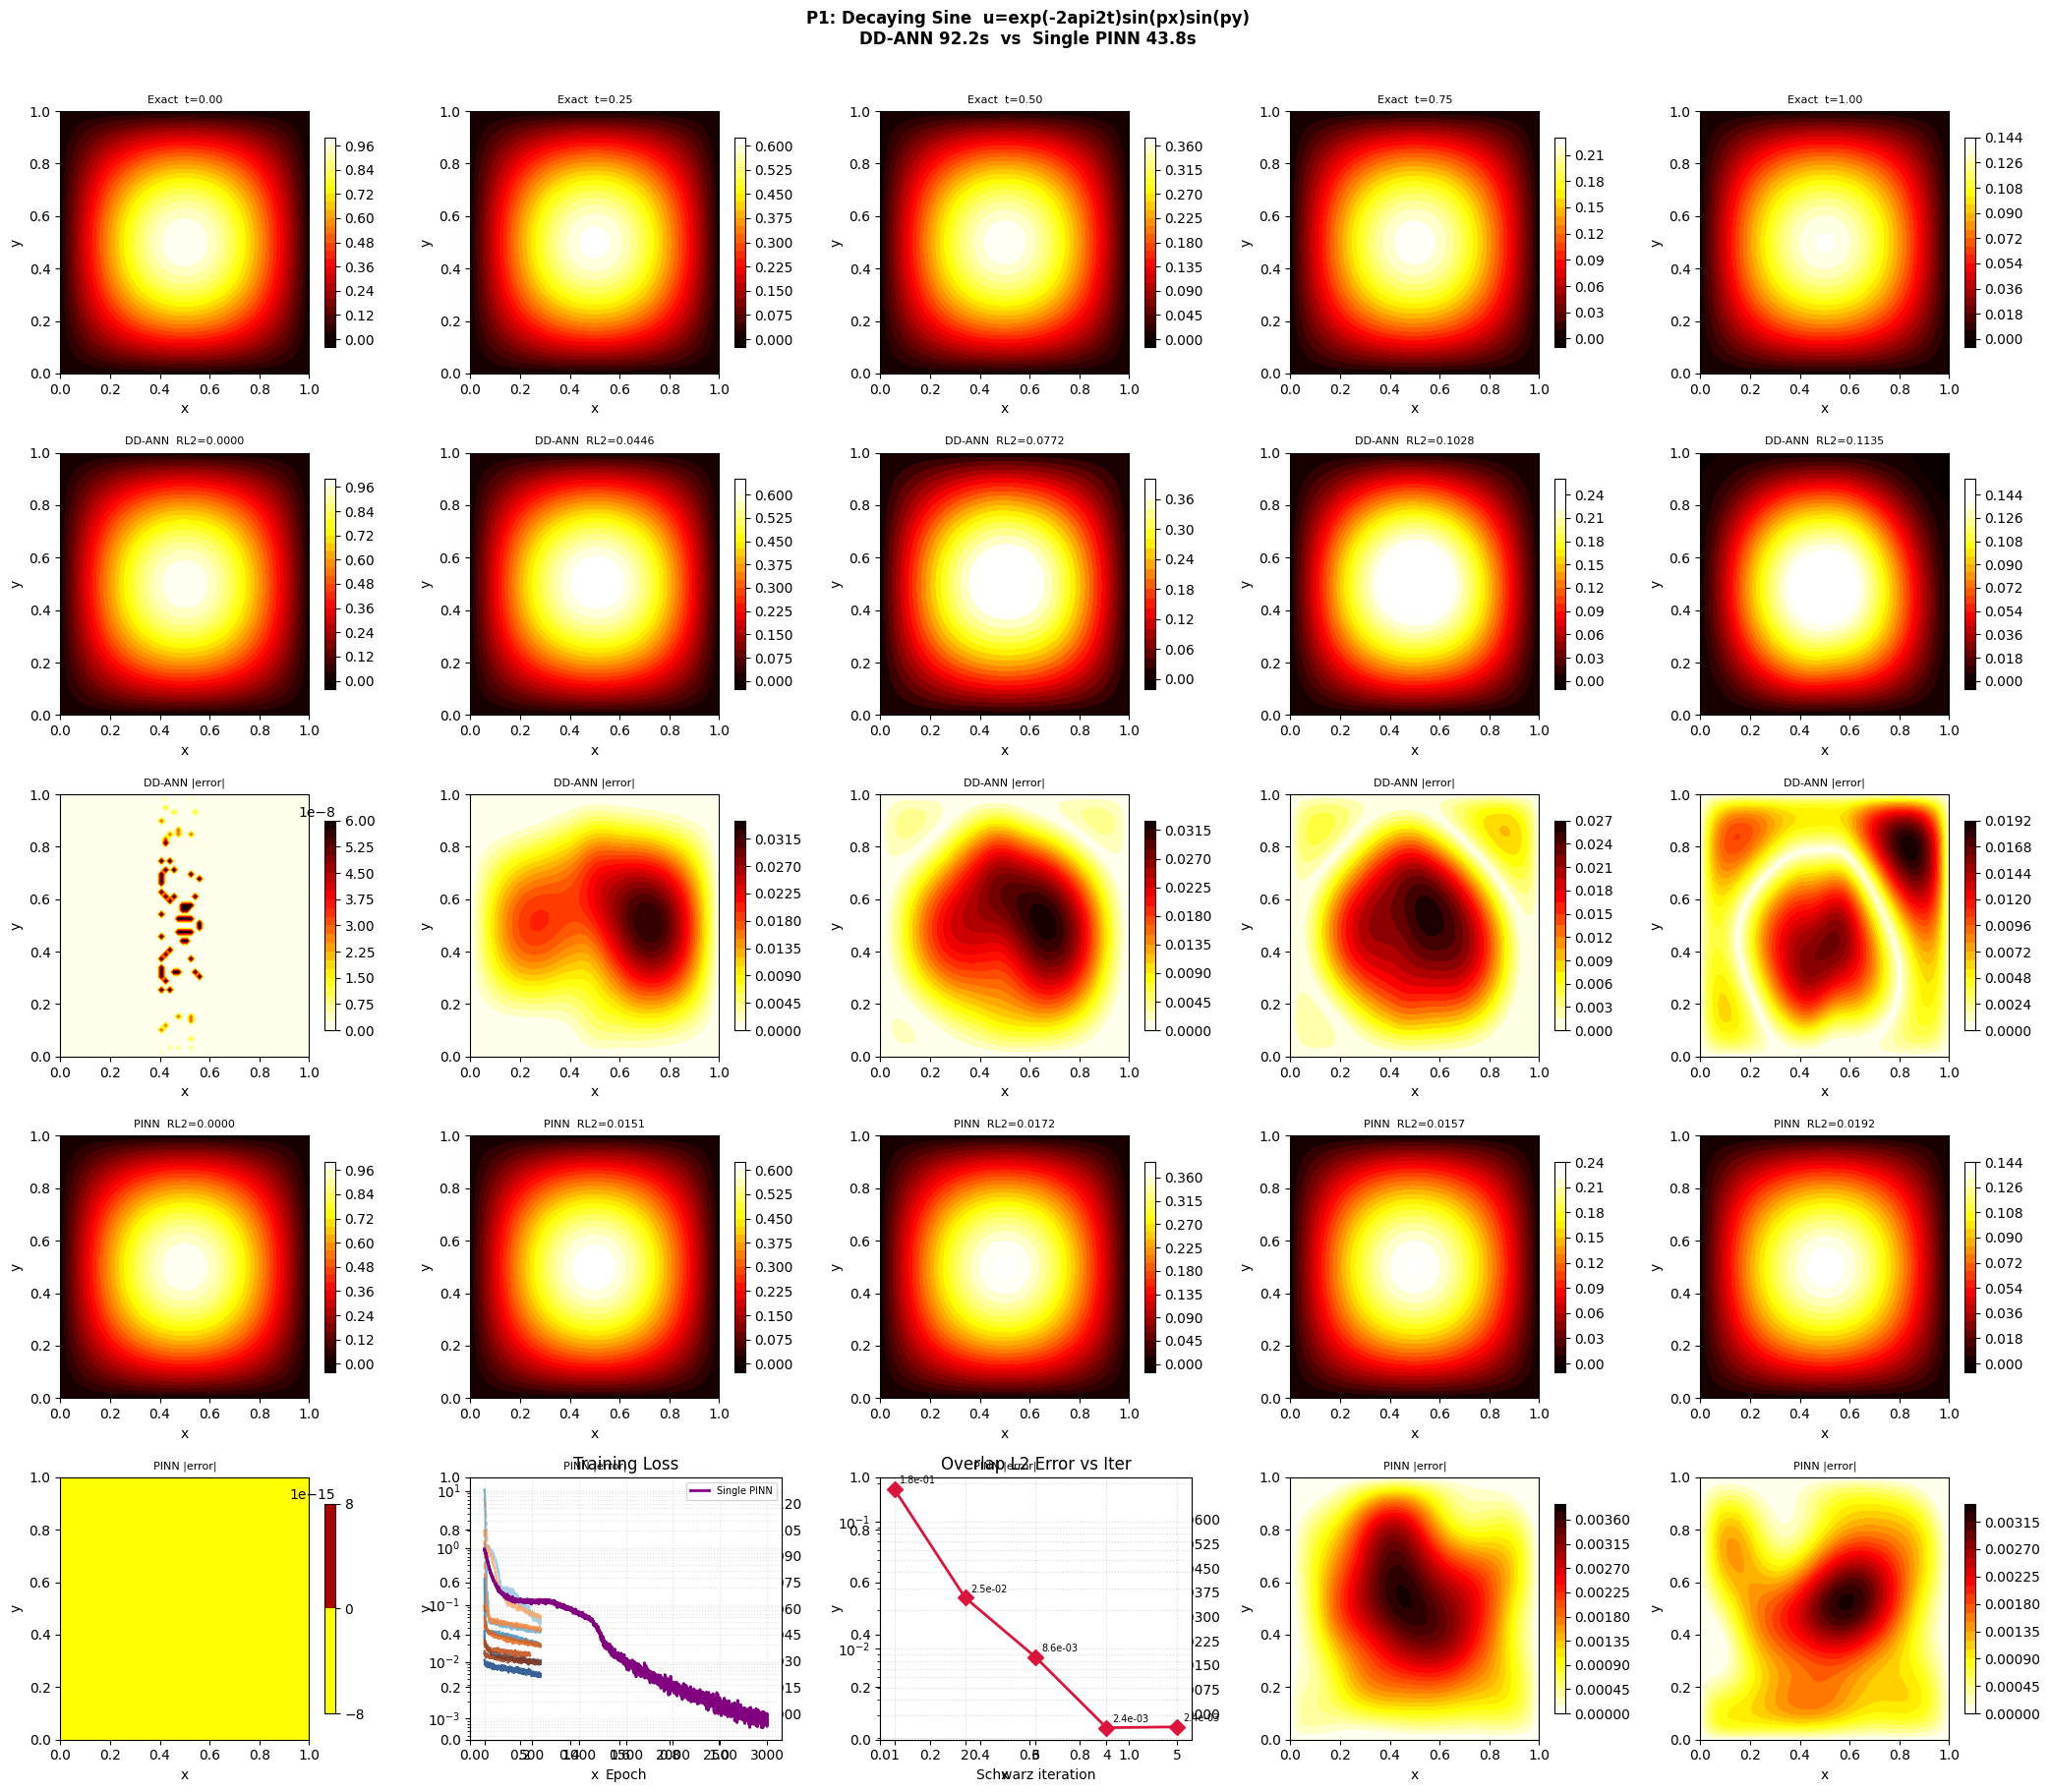

In [11]:
torch.manual_seed(42)
ALPHA1 = 0.1
T1     = 1.0
T_SNAPS1 = [0.0, 0.25, 0.5, 0.75, 1.0]
prob_name = "P1: Decaying Sine  u=exp(-2api2t)sin(px)sin(py)"

ic1    = lambda xy: (torch.sin(torch.pi*xy[:,0:1])
                     * torch.sin(torch.pi*xy[:,1:2]))

exact1 = lambda xyt: (torch.exp(-2*ALPHA1*torch.pi**2*xyt[:,2:3])
                      * torch.sin(torch.pi*xyt[:,0:1])
                      * torch.sin(torch.pi*xyt[:,1:2]))

# ── DD-ANN ──────────────────────────────────────────────────────────────
print("Running DD-ANN...")
net1, net2, lhist, ov_errs, dd_time, i_times = schwarz_dd_heat(
    ic1, alpha=ALPHA1, T=T1,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_int=N_INT, n_if=N_IF,
    lambda_if=LAMBDA_IF, lr=LR,
    decay_steps=DECAY_STEPS, patience=PATIENCE
)

# ── Single PINN ──────────────────────────────────────────────────────────
print("\nRunning Single PINN (baseline)...")
torch.manual_seed(42)
pinn1    = HardBC_Heat_Global(ic1).to(device)
ph1, pinn_time1 = train_single_pinn(
    pinn1, ALPHA1, T1,
    epochs=PINN_EPOCHS, n_int=PINN_N_INT
)

# ── Evaluate both ────────────────────────────────────────────────────────
print("\nEvaluating DD-ANN...")
X1, Y1, res_dd1 = evaluate_at_snaps(
    (net1, net2), exact1, X_A, X_B, T1, T_SNAPS1, is_dd=True
)
print("Evaluating Single PINN...")
X1, Y1, res_pinn1 = evaluate_at_snaps(
    pinn1, exact1, X_A, X_B, T1, T_SNAPS1, is_dd=False
)

print_stats(lhist, ov_errs, i_times, dd_time,
             EPOCHS_PER_ITER, SCHWARZ_ITERS,
             res_dd1, res_pinn1, T_SNAPS1)

timing_records.append({
    'problem' : prob_name,
    'dd_time' : dd_time,
    'pinn_time': pinn_time1,
    'dd_mean_rl2'  : np.mean([res_dd1[t]['rel_l2']   for t in T_SNAPS1]),
    'pinn_mean_rl2': np.mean([res_pinn1[t]['rel_l2'] for t in T_SNAPS1])
})

plot_comparison(X1, Y1, res_dd1, res_pinn1, T_SNAPS1,
                lhist, ov_errs, ph1, prob_name, dd_time, pinn_time1)

## Problem 2 — Higher Spatial Mode ($\alpha=0.1$, $T=0.5$)

$$u = e^{-5\alpha\pi^2 t}\sin(\pi x)\sin(2\pi y), \quad u_0 = \sin(\pi x)\sin(2\pi y)$$

Decays **5× faster** than Problem 1 (higher mode). Two half-waves in $y$.

Running DD-ANN...

── Schwarz Iteration 1/5  (lr=1.00e-03) ──
  Ω₁:  600 ep | t=9.04s | loss=3.3781e+00
  Ω₂:  600 ep | t=8.93s | loss=2.1926e+00
  Overlap L2: 9.6499e-02

── Schwarz Iteration 2/5  (lr=9.00e-04) ──
  Ω₁:  600 ep | t=8.79s | loss=6.7939e-01
  Ω₂:  600 ep | t=9.18s | loss=7.8145e-01
  Overlap L2: 5.1050e-02

── Schwarz Iteration 3/5  (lr=8.10e-04) ──
  Ω₁:  600 ep | t=9.30s | loss=3.2006e-01
  Ω₂:  600 ep | t=9.28s | loss=3.9235e-01
  Overlap L2: 2.5369e-02

── Schwarz Iteration 4/5  (lr=7.29e-04) ──
  Ω₁:  600 ep | t=9.04s | loss=2.1175e-01
  Ω₂:  600 ep | t=8.82s | loss=1.9757e-01
  Overlap L2: 1.1220e-02

── Schwarz Iteration 5/5  (lr=6.56e-04) ──
  Ω₁:  600 ep | t=8.79s | loss=1.4102e-01
  Ω₂:  600 ep | t=9.04s | loss=1.5224e-01
  Overlap L2: 7.1492e-03

Running Single PINN...
  Single PINN: 3000 epochs | t=48.28s | loss=3.3762e-01

Evaluating...

─────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)     

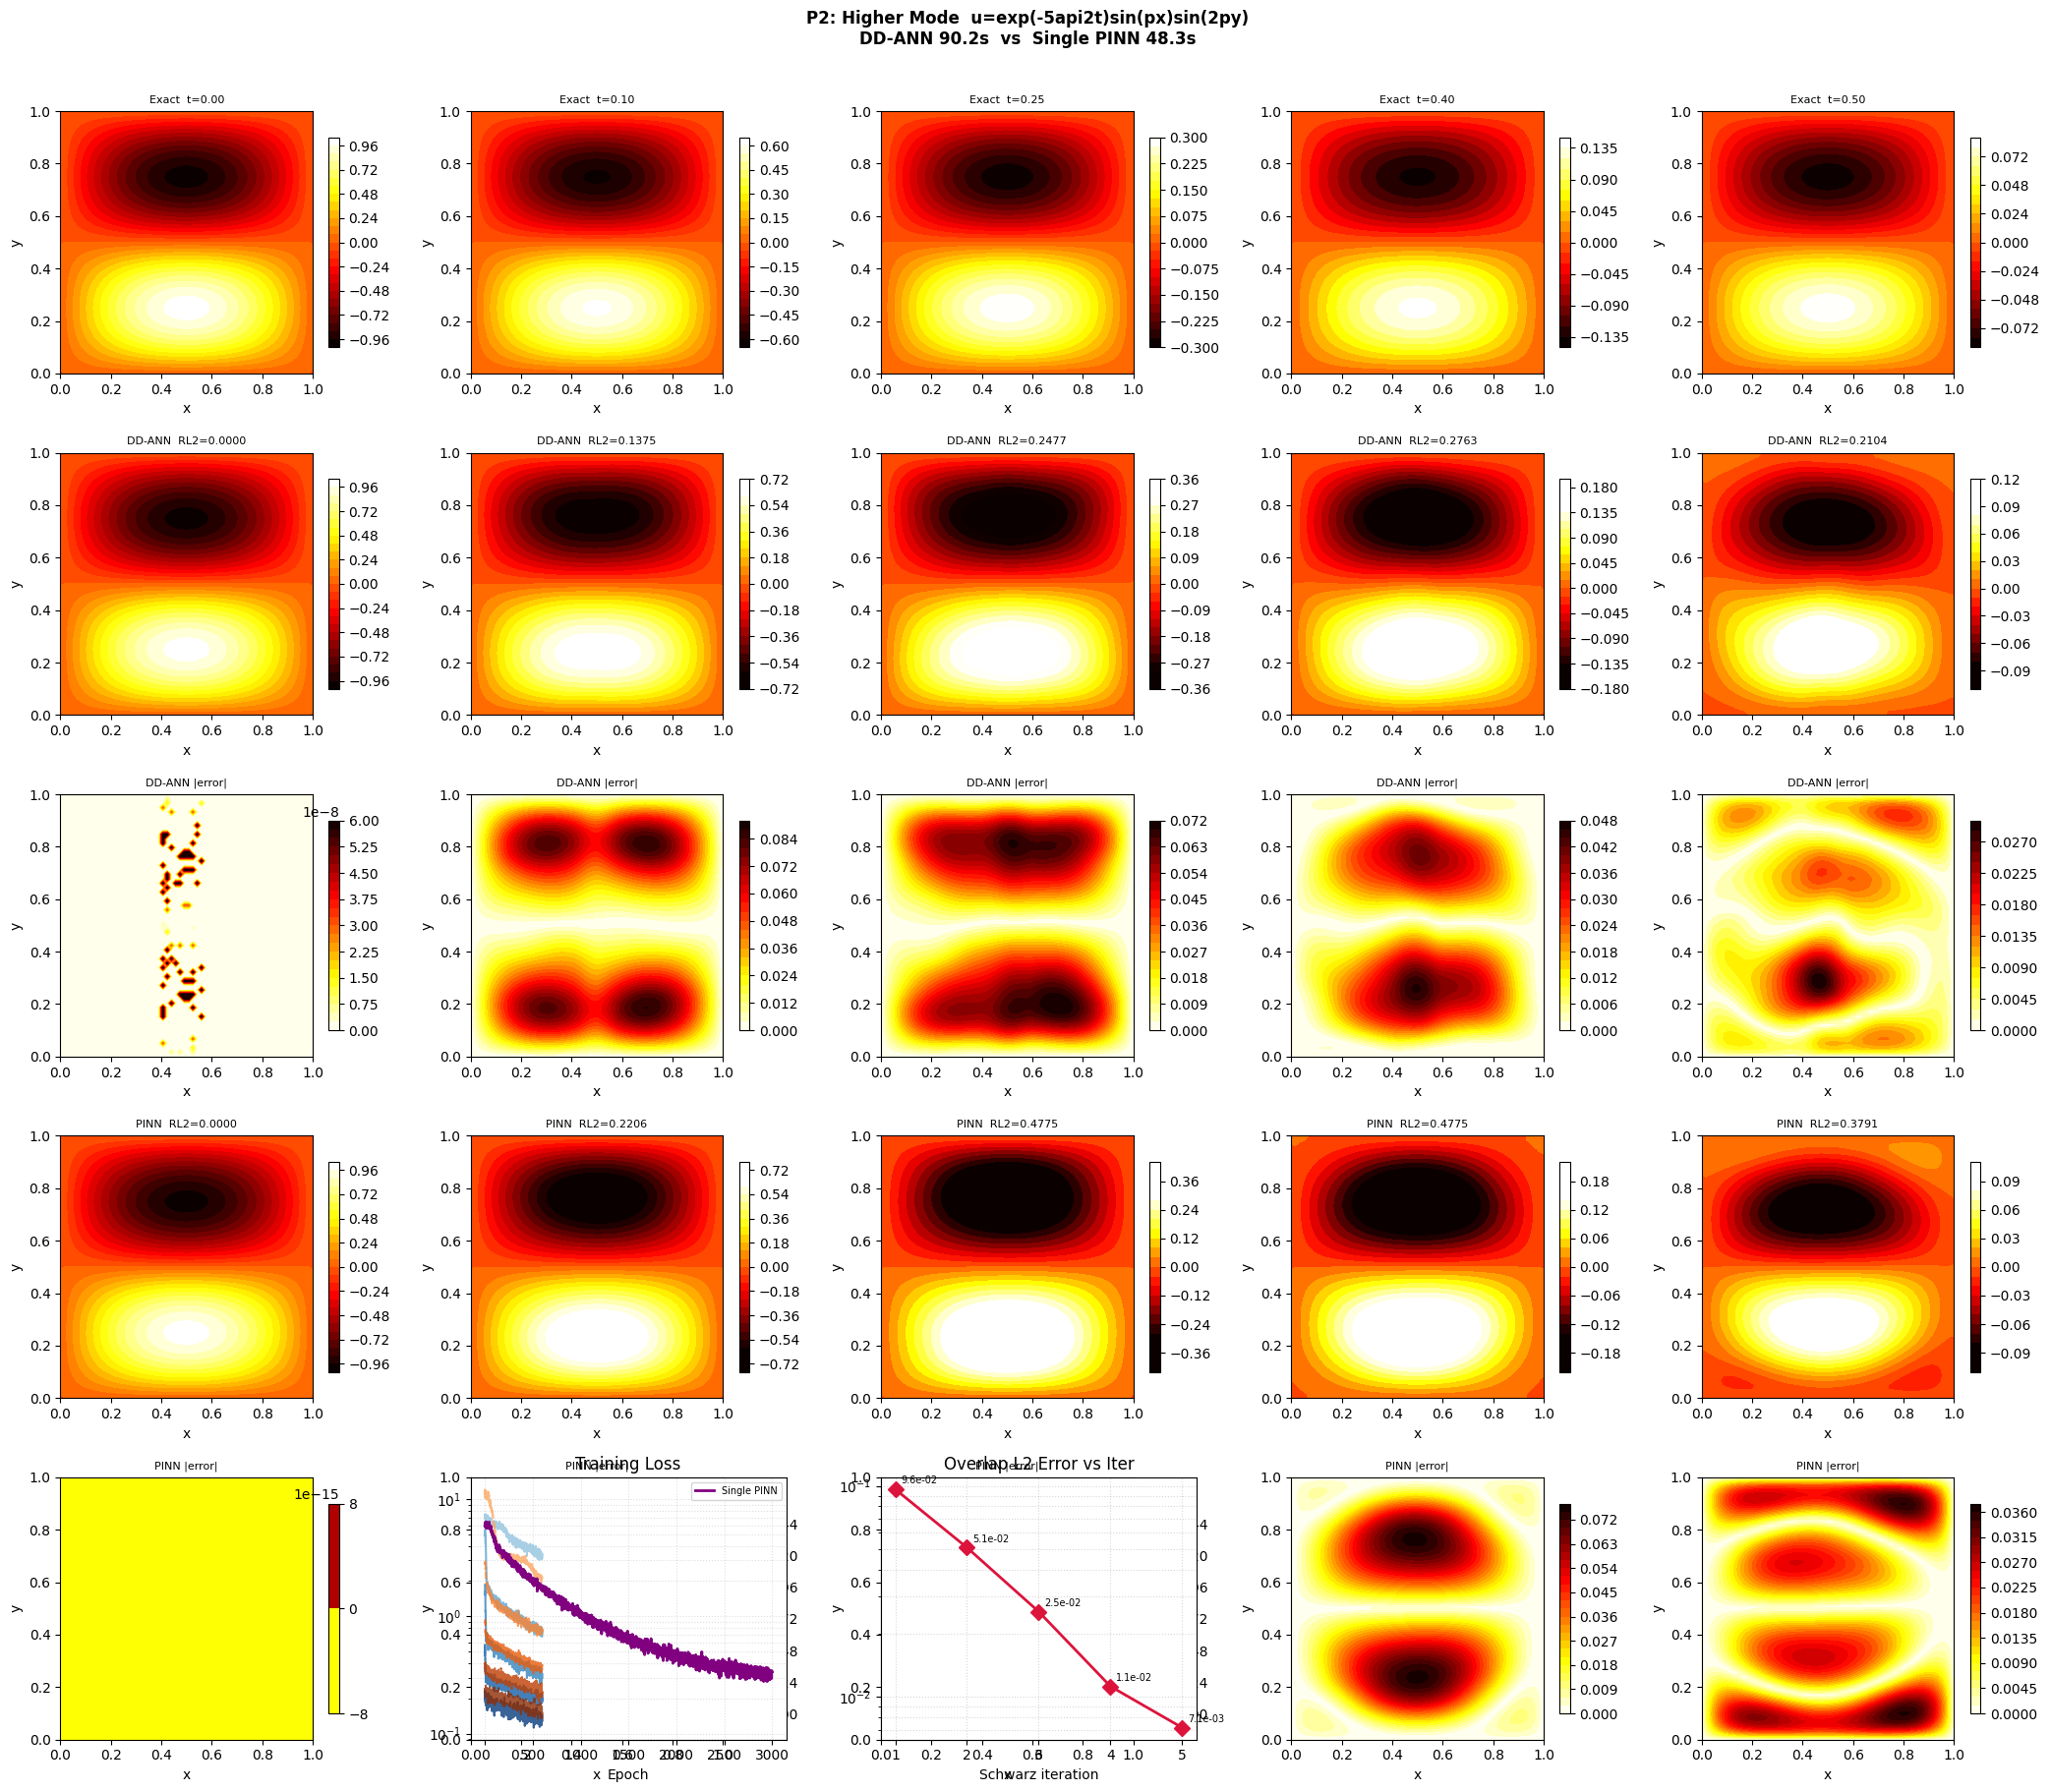

In [12]:
torch.manual_seed(42)
ALPHA2 = 0.1
T2     = 0.5
T_SNAPS2 = [0.0, 0.1, 0.25, 0.4, 0.5]
prob_name = "P2: Higher Mode  u=exp(-5api2t)sin(px)sin(2py)"

ic2    = lambda xy: (torch.sin(torch.pi*xy[:,0:1])
                     * torch.sin(2*torch.pi*xy[:,1:2]))

exact2 = lambda xyt: (torch.exp(-5*ALPHA2*torch.pi**2*xyt[:,2:3])
                      * torch.sin(torch.pi*xyt[:,0:1])
                      * torch.sin(2*torch.pi*xyt[:,1:2]))

print("Running DD-ANN...")
net1, net2, lhist, ov_errs, dd_time, i_times = schwarz_dd_heat(
    ic2, alpha=ALPHA2, T=T2,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_int=N_INT, n_if=N_IF,
    lambda_if=LAMBDA_IF, lr=LR,
    decay_steps=DECAY_STEPS, patience=PATIENCE
)

print("\nRunning Single PINN...")
torch.manual_seed(42)
pinn2    = HardBC_Heat_Global(ic2).to(device)
ph2, pinn_time2 = train_single_pinn(
    pinn2, ALPHA2, T2,
    epochs=PINN_EPOCHS, n_int=PINN_N_INT
)

print("\nEvaluating...")
X2, Y2, res_dd2 = evaluate_at_snaps(
    (net1,net2), exact2, X_A,X_B,T2, T_SNAPS2, is_dd=True)
X2, Y2, res_pinn2 = evaluate_at_snaps(
    pinn2, exact2, X_A,X_B,T2, T_SNAPS2, is_dd=False)

print_stats(lhist, ov_errs, i_times, dd_time,
             EPOCHS_PER_ITER, SCHWARZ_ITERS,
             res_dd2, res_pinn2, T_SNAPS2)

timing_records.append({
    'problem' : prob_name,
    'dd_time' : dd_time, 'pinn_time': pinn_time2,
    'dd_mean_rl2'  : np.mean([res_dd2[t]['rel_l2']   for t in T_SNAPS2]),
    'pinn_mean_rl2': np.mean([res_pinn2[t]['rel_l2'] for t in T_SNAPS2])
})

plot_comparison(X2, Y2, res_dd2, res_pinn2, T_SNAPS2,
                lhist, ov_errs, ph2, prob_name, dd_time, pinn_time2)

## Problem 3 — Two-Mode Superposition ($\alpha=0.1$, $T=0.5$)

$$u = e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y) + 0.5\,e^{-8\alpha\pi^2 t}\sin(2\pi x)\sin(2\pi y)$$

Both modes satisfy the heat equation independently — their superposition also does.
The second mode decays **4× faster**, so at $T=0.5$ only the first mode dominates.
This is the hardest problem: the IC has two frequency components.

Running DD-ANN...

── Schwarz Iteration 1/5  (lr=1.00e-03) ──
  Ω₁:  600 ep | t=10.91s | loss=1.7708e+00
  Ω₂:  600 ep | t=10.38s | loss=3.4836e+00
  Overlap L2: 1.2531e-01

── Schwarz Iteration 2/5  (lr=9.00e-04) ──
  Ω₁:  600 ep | t=10.31s | loss=1.1983e+00
  Ω₂:  251 ep | t=4.48s | loss=3.2390e+00
  Overlap L2: 3.0246e-02

── Schwarz Iteration 3/5  (lr=8.10e-04) ──
  Ω₁:  455 ep | t=8.02s | loss=1.0254e+00
  Ω₂:  193 ep | t=3.31s | loss=3.4231e+00
  Overlap L2: 2.5009e-02

── Schwarz Iteration 4/5  (lr=7.48e-04) ──
  Ω₁:  600 ep | t=10.20s | loss=7.5235e-01
  Ω₂:  600 ep | t=10.21s | loss=3.2220e+00
  Overlap L2: 2.4237e-02

── Schwarz Iteration 5/5  (lr=6.73e-04) ──
  Ω₁:  502 ep | t=8.59s | loss=5.9103e-01
  Ω₂:  600 ep | t=10.19s | loss=2.7149e+00
  Overlap L2: 3.3286e-02

Running Single PINN...
  Single PINN: 872 epochs | t=15.52s | loss=3.9028e+00

Evaluating...

─────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)

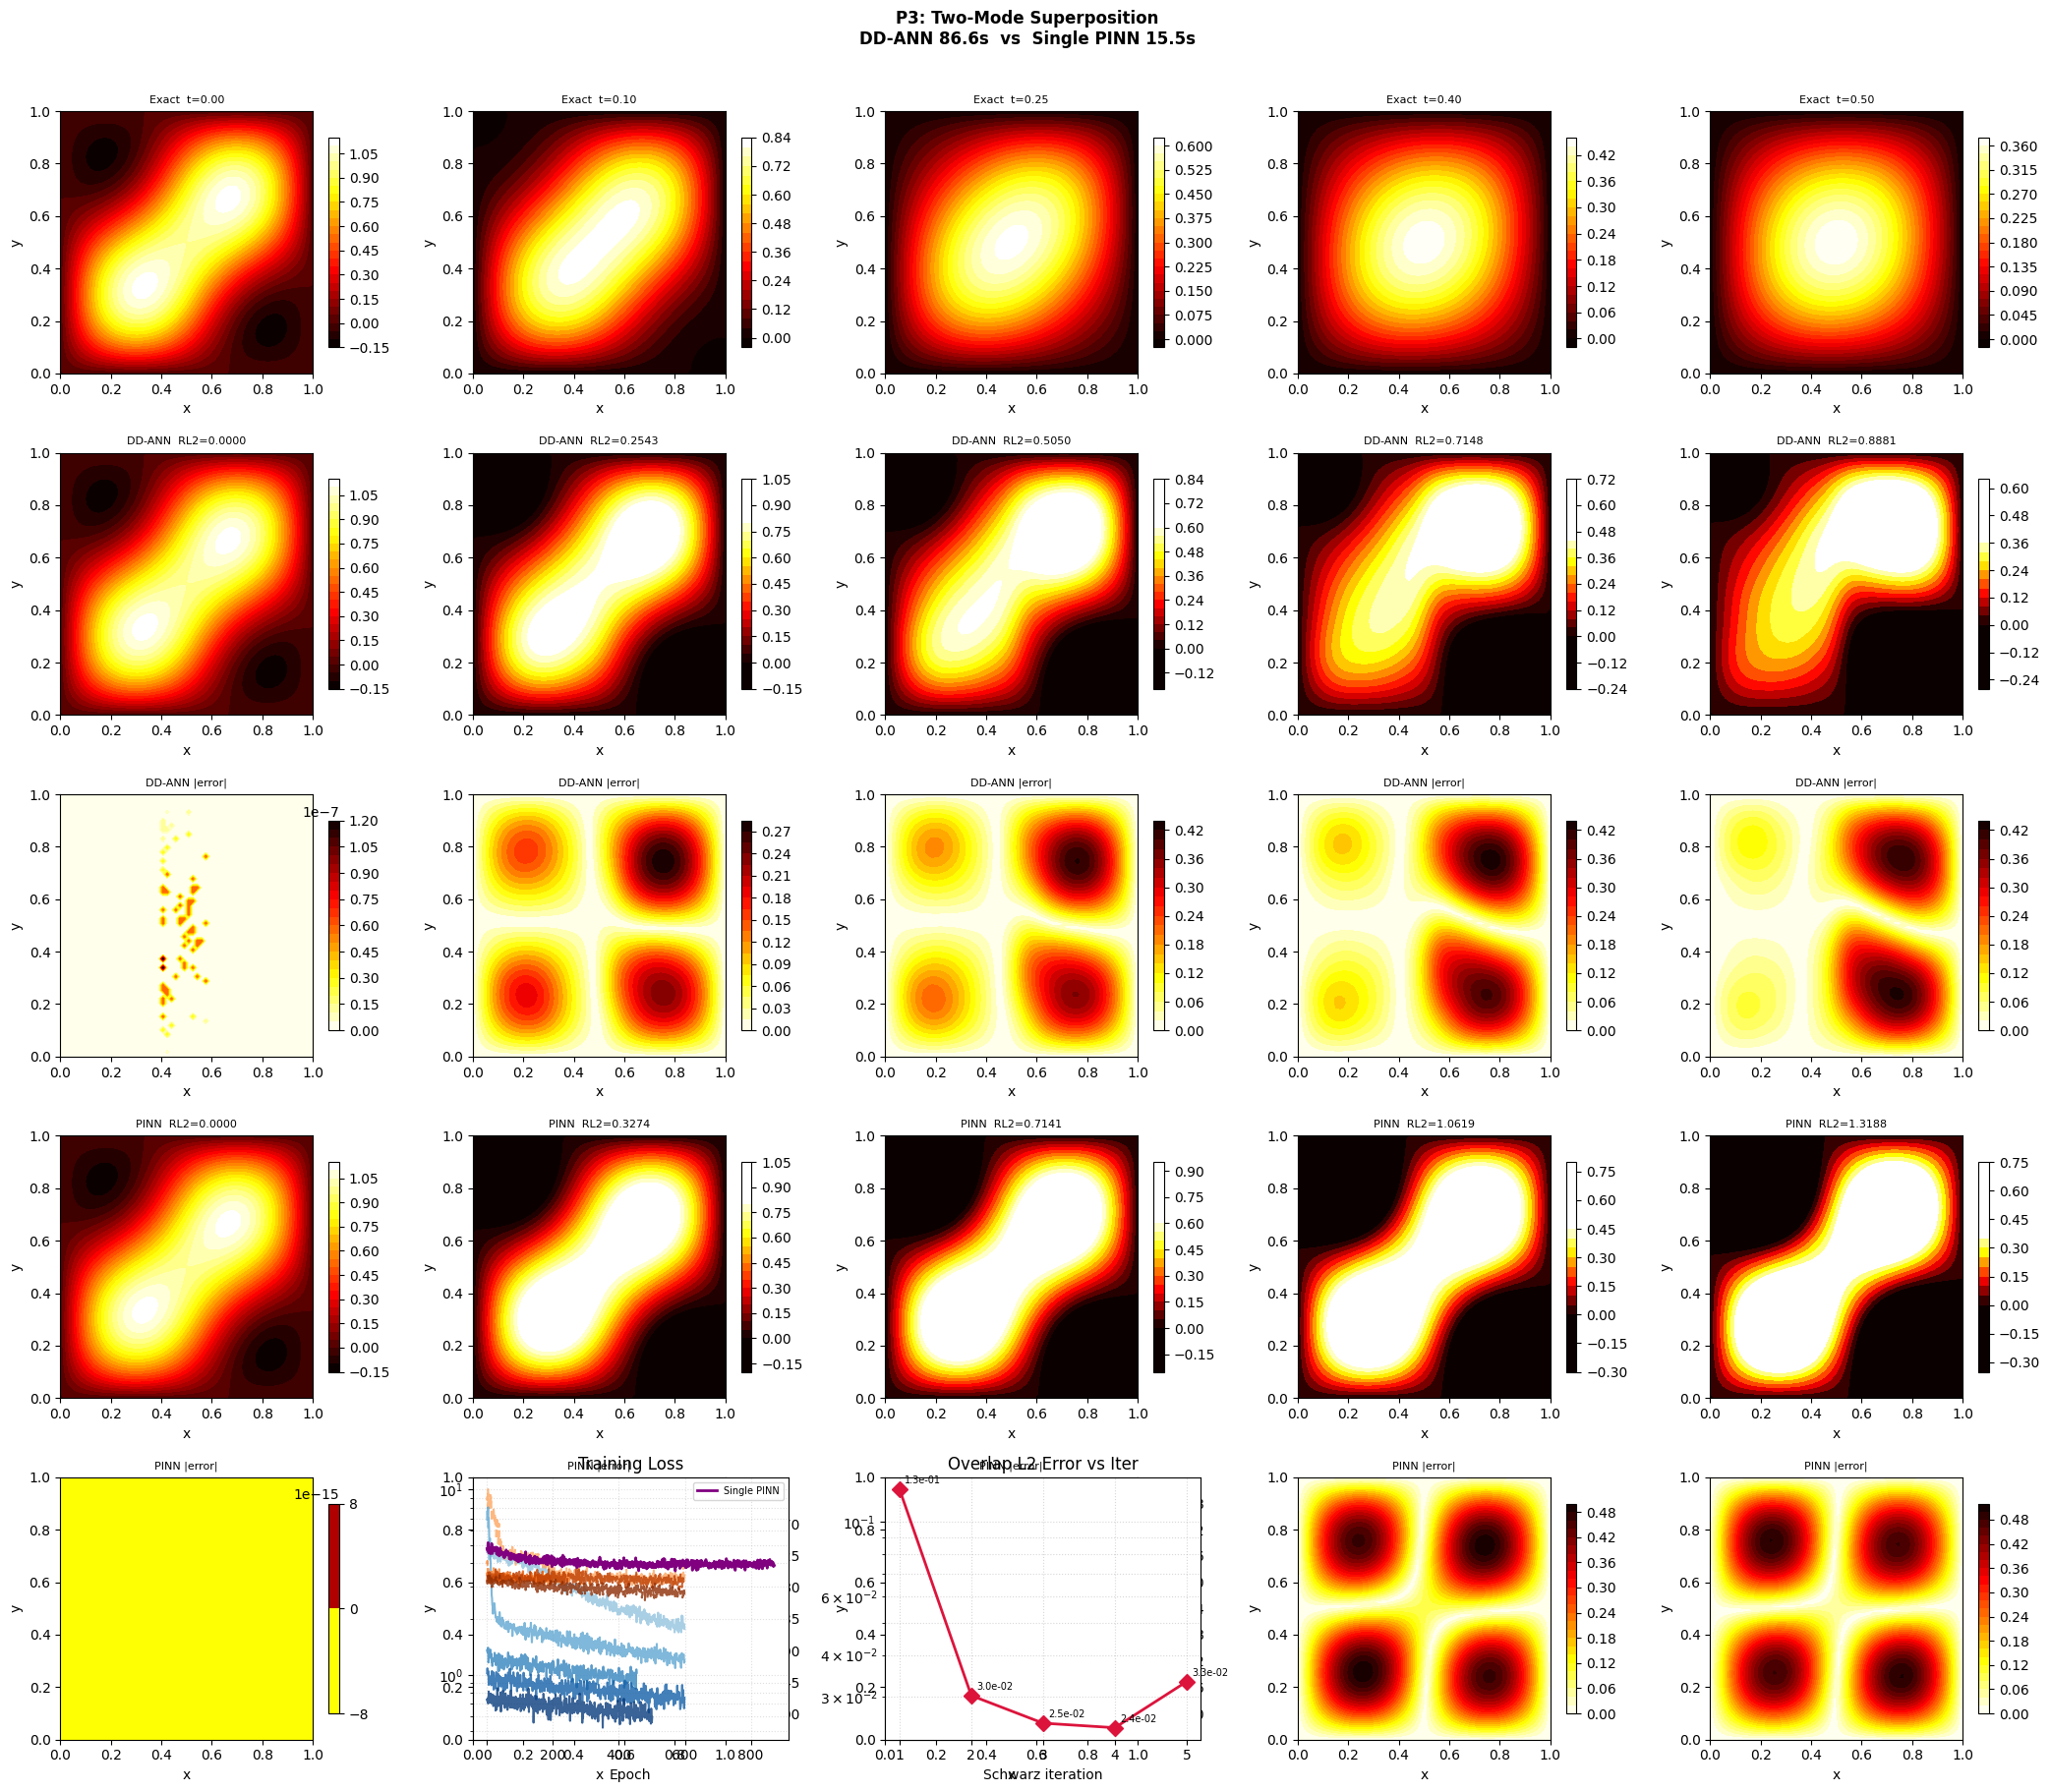

In [13]:
torch.manual_seed(42)
ALPHA3 = 0.1
T3     = 0.5
T_SNAPS3 = [0.0, 0.1, 0.25, 0.4, 0.5]
prob_name = "P3: Two-Mode Superposition"

def ic3(xy):
    return (torch.sin(torch.pi*xy[:,0:1]) * torch.sin(torch.pi*xy[:,1:2])
            + 0.5*torch.sin(2*torch.pi*xy[:,0:1]) * torch.sin(2*torch.pi*xy[:,1:2]))

def exact3(xyt):
    m1 = (torch.exp(-2*ALPHA3*torch.pi**2*xyt[:,2:3])
          * torch.sin(torch.pi*xyt[:,0:1])
          * torch.sin(torch.pi*xyt[:,1:2]))
    m2 = (0.5*torch.exp(-8*ALPHA3*torch.pi**2*xyt[:,2:3])
          * torch.sin(2*torch.pi*xyt[:,0:1])
          * torch.sin(2*torch.pi*xyt[:,1:2]))
    return m1 + m2

print("Running DD-ANN...")
net1, net2, lhist, ov_errs, dd_time, i_times = schwarz_dd_heat(
    ic3, alpha=ALPHA3, T=T3,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_int=N_INT, n_if=N_IF,
    lambda_if=LAMBDA_IF, lr=LR,
    decay_steps=DECAY_STEPS, patience=PATIENCE
)

print("\nRunning Single PINN...")
torch.manual_seed(42)
pinn3    = HardBC_Heat_Global(ic3).to(device)
ph3, pinn_time3 = train_single_pinn(
    pinn3, ALPHA3, T3,
    epochs=PINN_EPOCHS, n_int=PINN_N_INT
)

print("\nEvaluating...")
X3, Y3, res_dd3 = evaluate_at_snaps(
    (net1,net2), exact3, X_A,X_B,T3, T_SNAPS3, is_dd=True)
X3, Y3, res_pinn3 = evaluate_at_snaps(
    pinn3, exact3, X_A,X_B,T3, T_SNAPS3, is_dd=False)

print_stats(lhist, ov_errs, i_times, dd_time,
             EPOCHS_PER_ITER, SCHWARZ_ITERS,
             res_dd3, res_pinn3, T_SNAPS3)

timing_records.append({
    'problem' : prob_name,
    'dd_time' : dd_time, 'pinn_time': pinn_time3,
    'dd_mean_rl2'  : np.mean([res_dd3[t]['rel_l2']   for t in T_SNAPS3]),
    'pinn_mean_rl2': np.mean([res_pinn3[t]['rel_l2'] for t in T_SNAPS3])
})

plot_comparison(X3, Y3, res_dd3, res_pinn3, T_SNAPS3,
                lhist, ov_errs, ph3, prob_name, dd_time, pinn_time3)

## Section 11 — Summary: DD-ANN vs Single PINN

In [14]:
print("\n" + "="*80)
print(f"  {'Problem':<40} {'DD Time':>8} {'PINN Time':>10} "
      f"{'DD RL2':>9} {'PINN RL2':>10} {'Winner':>8}")
print("="*80)

for r in timing_records:
    winner = "DD-ANN" if r['dd_mean_rl2'] < r['pinn_mean_rl2'] else "Single"
    print(f"  {r['problem']:<40} {r['dd_time']:>8.1f} {r['pinn_time']:>10.1f} "
          f"{r['dd_mean_rl2']:>9.5f} {r['pinn_mean_rl2']:>10.5f} {winner:>8}")

print("="*80)
print(f"\n  Architecture comparison:")
print(f"    Each subdomain  : 3 layers x 32 neurons = 2,273 params")
print(f"    DD-ANN total    : 2 x 2,273 = 4,546 params")
print(f"    Single PINN     : 2,273 params")
print(f"\n  Why DD-ANN can be more accurate despite smaller total budget:")
print(f"    Each subdomain solves a simpler (half-domain) problem")
print(f"    Hard BCs mean zero wasted capacity on boundary enforcement")
print(f"    LR scheduler decays continuously across ALL Schwarz iterations")


  Problem                                   DD Time  PINN Time    DD RL2   PINN RL2   Winner
  P1: Decaying Sine  u=exp(-2api2t)sin(px)sin(py)     92.2       43.8   0.06760    0.01345   Single
  P2: Higher Mode  u=exp(-5api2t)sin(px)sin(2py)     90.2       48.3   0.17437    0.31095   DD-ANN
  P3: Two-Mode Superposition                   86.6       15.5   0.47245    0.68445   DD-ANN

  Architecture comparison:
    Each subdomain  : 3 layers x 32 neurons = 2,273 params
    DD-ANN total    : 2 x 2,273 = 4,546 params
    Single PINN     : 2,273 params

  Why DD-ANN can be more accurate despite smaller total budget:
    Each subdomain solves a simpler (half-domain) problem
    Hard BCs mean zero wasted capacity on boundary enforcement
    LR scheduler decays continuously across ALL Schwarz iterations
